In [5]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

## Lab 12 - Permutation - Example Code (two continuous variables)

### 1. Data Exploration

In [6]:
#load dataset
tbl_all = Table.read_table('https://raw.githubusercontent.com/lujiec2020/UMBC-IS296-Fall2022/main/data/baby.csv')
tbl_all

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [7]:
#select only relevant columns
tbl = tbl_all.select('Gestational Days', 'Birth Weight')
tbl

Gestational Days,Birth Weight
284,120
282,113
279,128
282,108
286,136
244,138
245,132
289,120
299,143
351,140


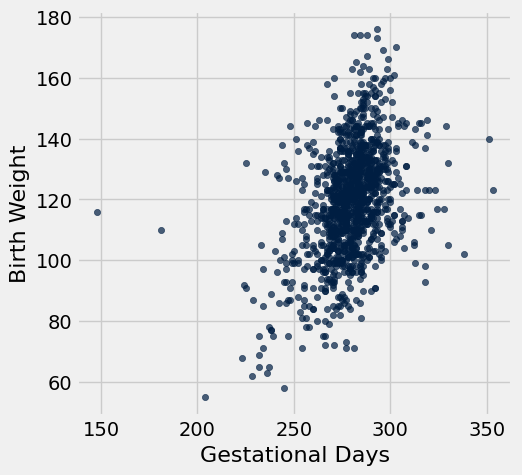

In [8]:
tbl.scatter('Gestational Days', 'Birth Weight')

### 2. Permuation Test

In [9]:
#step1: determine test statistics
correlation_matrix = np.corrcoef(tbl.column('Gestational Days'),tbl.column('Birth Weight'))
correlation_coefficient = correlation_matrix[0, 1]
correlation_coefficient

0.40754279338885085

In [10]:
def get_cor(table, var1, var2):
    """
    table: name of table,
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    return: correlation coefficient as a numeric value"""
    correlation_matrix = np.corrcoef(table.column(var1),table.column(var2))
    my_result = correlation_matrix[0, 1]
    return my_result

In [11]:
#test function above
observed_correlation = get_cor(tbl,'Gestational Days', 'Birth Weight') # update
observed_correlation

0.40754279338885085

In [12]:
#step 2: run simulation
#2a function to run one iteration of simulation
def one_simulated_cor(table, var1, var2):
    """
    var1: a string, the name of the column with the first variable
    var2: a string, the name of the column with the second variable
    Returns: correlation between two variables after shuffling"""
    shuffled_var2 = table.sample(with_replacement = False).column(var2)
    # table of numerical variable and shuffled labels
    shuffled_table = table.select(var1).with_column('Shuffled var2', shuffled_var2)
    return get_cor(shuffled_table, var1, 'Shuffled var2')

In [13]:
#test the function above
one_simulated_cor(tbl, 'Gestational Days', 'Birth Weight') # update

0.0211989014730289

In [14]:
#2b: function to run multiple iterations of simulation
cor_list = make_array()
for i in np.arange(100):
    new_cor = one_simulated_cor(tbl, 'Gestational Days', 'Birth Weight') # update
    cor_list= np.append(cor_list, new_cor)
cor_list

array([ 0.02661414, -0.01467703, -0.01591754, -0.04335105, -0.01740208,
       -0.02198062, -0.02238735,  0.02147489,  0.01026385,  0.06280964,
        0.0046191 ,  0.01309929, -0.01228608, -0.01868907, -0.00352699,
       -0.02254132, -0.04485011, -0.02772124, -0.00866042,  0.00443317,
       -0.01489492, -0.01795697, -0.00282685, -0.03370589,  0.04486731,
        0.00850041, -0.0322533 ,  0.04129105, -0.01722196, -0.00760294,
       -0.0019582 , -0.01110658, -0.00195239,  0.04247636, -0.04955649,
       -0.02594909,  0.0179393 , -0.02115846, -0.04839152, -0.03300284,
       -0.021908  ,  0.00515656, -0.04386817,  0.00425015, -0.03439441,
        0.02350851,  0.01117607,  0.00531053, -0.03086463,  0.01390402,
       -0.00951745,  0.04568657,  0.02741306, -0.04618649,  0.01174839,
       -0.05206365,  0.07264073,  0.01329394,  0.02736948, -0.02182665,
       -0.01883433, -0.02142574,  0.02657346,  0.03432155, -0.00972081,
       -0.0016793 ,  0.02411569, -0.00940996, -0.02569634,  0.04

Observed correlation: 0.407542793389
p-value= 0.0


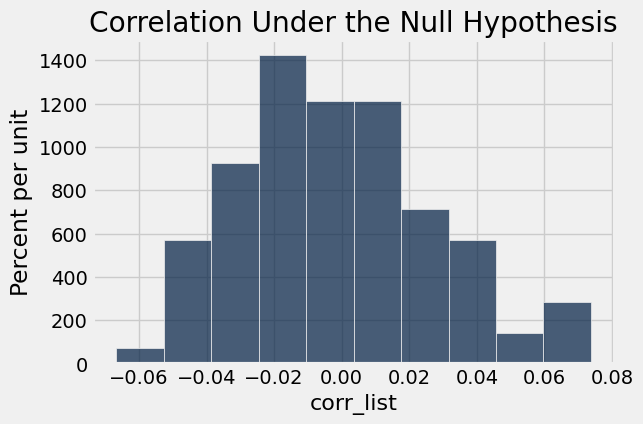

In [16]:
# step 3: visualize and interprete results
Table().with_column('corr_list', cor_list).hist()
print('Observed correlation:',observed_correlation)
print('p-value=',np.mean(cor_list>observed_correlation)) # update: change the sign < or > to according to your problem
plots.title('Correlation Under the Null Hypothesis');